# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary.

The business objective is framed as a supervised machine learning regression task to predict used car prices.
By leveraging features such as mileage, condition, and make, the model will identify key price drivers through
exploratory data analysis (EDA) and feature engineering. The final regression model
(e.g., Linear Regression or Random Forest) will quantify feature impact, enabling data-driven pricing strategies.

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

Getting to know the dataset involves performing Exploratory Data Analysis (EDA) to evaluate initial information, spot data quality issues, and align features with your business goals.A structured, phased approach to this process includes the following steps:
1. Perform Structural Inspection

* Get dimensions: Check the number of rows and columns to understand the overall size and computational needs.

* Review data types: Identify whether columns are numerical, categorical, or datetime.

* Sample the data: Display the first and last few rows to get a literal look at the data structure and verify if the data makes intuitive sense.

2. Identify Data Quality Issues

* Check for missing values: Identify the count and percentage of missing values in each column. Determine if missing values are random or systematic.

* Find duplicates: Check for duplicate rows or records that might skew analysis and inflate sample sizes.

* Identify anomalies and outliers: Look for extreme values or errors (e.g., negative ages, impossible dates) that could distort future models.

In [44]:
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from warnings import filterwarnings
filterwarnings('ignore')
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.metrics import mean_squared_error
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Ridge
from datetime import datetime

In [45]:
df = pd.read_csv('data/vehicles.csv')

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

In [47]:
df.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [48]:
# Get total rows count
total_count = df.shape[0]
print(f'Total count: {total_count}\n')

# find duplicate
df_duplicate_count = df.duplicated().sum()
print(f'\nTotal duplicate count: {df_duplicate_count}\n')

# Get a summary of null values count per column
null_counts = df.isnull().sum()
df_null_columns = null_counts[null_counts > 0].sort_values(ascending=False).to_frame()

df_null_columns.rename(columns={0: 'null counts'}, inplace=True)
df_null_columns['Percentage of Null values (%)'] = (df_null_columns['null counts'] / total_count) * 100
df_null_columns


Total count: 426880


Total duplicate count: 0



,null counts,Percentage of Null values (%)
size,306361,71.767476
cylinders,177678,41.622470
condition,174104,40.785232
VIN,161042,37.725356
drive,130567,30.586347
paint_color,130203,30.501078
type,92858,21.752717
manufacturer,17646,4.133714
title_status,8242,1.930753
model,5277,1.236179


### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`.

In [49]:
# Based on https://www.hubresearch.ca/bridging-the-data-gap-how-to-deal-with-missing-data-in-observational-studies/#:~:text=As%20a%20rule%20of%20thumb%2C%20if%20less,be%20deleted%20without%20any%20significant%20ramifications%20(3),
# if less than 5% of the observations are missing, the missing data can simply be deleted without any significant ramification
# manufacturer, title_status, model, odometer, fuel, transimission & year columns have total null values that is around 1 - 4% of the total count (see above).
# So we drop these rows.

df_clean = df.dropna(subset=['manufacturer', 'title_status', 'model', 'odometer', 'fuel', 'transmission', 'year'], how='any')

# VIN column is not needed
df_clean.drop(columns=['VIN', 'id'], inplace=True)

# Convert 'year' to vehicle age
df_clean['vehicle_age'] = datetime.now().year - df_clean['year']
df_clean = df_clean.drop(columns=['year'])

df_clean.reset_index()

print(f'total records count after dropping null values: {df_clean.shape[0]}\n')

# Fill missing numerical values with median ('price', 'year' & 'odometer' columns)
numeric_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns
df_clean[numeric_cols] = df_clean[numeric_cols].fillna(df_clean[numeric_cols].median())

# Replace null value with 'Unknown' for cylinders, condition, drive, paint_color & type columns
df_clean = df_clean.fillna({'size': 'Unknown', 'cylinders': 'Unknown', 'condition': 'Unknown',
                            'drive': 'Unknown', 'paint_color': 'Unknown', 'type': 'Unknown'})

print(f'total records count after cleaning null values: {df_clean.shape[0]}\n')
print('We will use this dataframe after cleaning, \"df_clean\", for our analysis')
df_clean.head()

total records count after dropping null values: 389604

total records count after cleaning null values: 389604

We will use this dataframe after cleaning, "df_clean", for our analysis


,region,price,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,paint_color,state,vehicle_age
27,auburn,33590,gmc,sierra 1500 crew cab slt,good,8 cylinders,gas,57923.0,clean,other,Unknown,Unknown,pickup,white,al,12.0
28,auburn,22590,chevrolet,silverado 1500,good,8 cylinders,gas,71229.0,clean,other,Unknown,Unknown,pickup,blue,al,16.0
29,auburn,39590,chevrolet,silverado 1500 crew,good,8 cylinders,gas,19160.0,clean,other,Unknown,Unknown,pickup,red,al,6.0
30,auburn,30990,toyota,tundra double cab sr,good,8 cylinders,gas,41124.0,clean,other,Unknown,Unknown,pickup,red,al,9.0
31,auburn,15000,ford,f-150 xlt,excellent,6 cylinders,gas,128000.0,clean,automatic,rwd,full-size,truck,black,al,13.0


The column that correlates most with 'price' is: vehicle_age
Correlation value: 0.00
odometer       0.000872
vehicle_age    0.004772
Name: price, dtype: float64


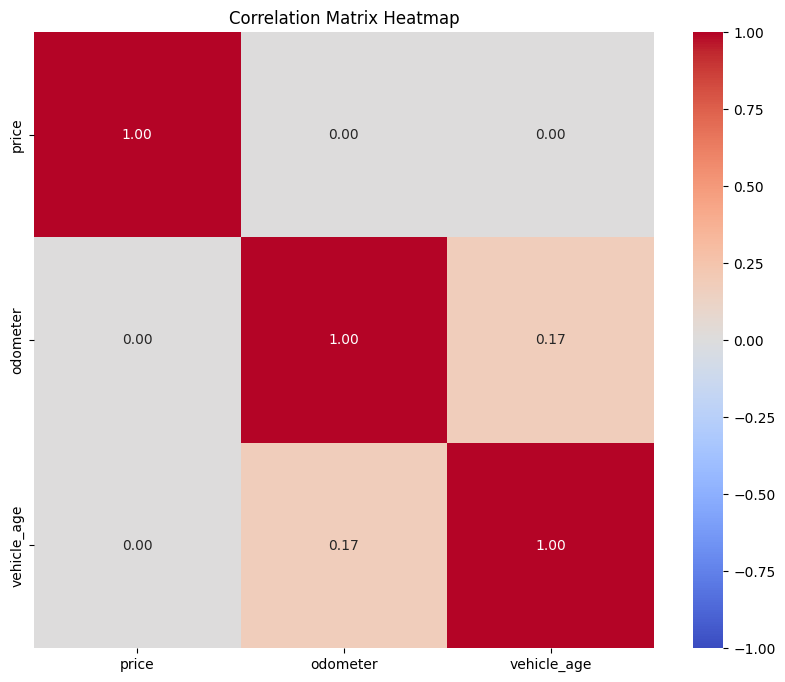

In [50]:
numeric_df = df_clean.select_dtypes(include=['number'])

# 1. Calculate the correlation matrix
correlation_matrix = numeric_df.corr()

# 2. Find which column correlates most with 'price'
# We take the absolute value to check for the strongest relationship,
# then exclude 'price' itself (which always has a correlation of 1.0)
top_correlations = correlation_matrix['price'].abs().drop('price')

highest_corr_column = top_correlations.idxmax()
highest_corr_value = correlation_matrix.loc[highest_corr_column, 'price']

print(f"The column that correlates most with 'price' is: {highest_corr_column}")
print(f"Correlation value: {highest_corr_value:.2f}")

print(top_correlations)

# 3. Display the Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title("Correlation Matrix Heatmap")
plt.savefig('images/correlation_heatmap.png', bbox_inches='tight')
plt.show()

We can see from correlation data above that odometer has the strongest correlation to the car price. Next to it is the vehicle_age. We will build the preliminary model on these 2 features.
But first, let's check if there's any outlier within these 2 features. If the percentage of outliers is small, let's remove it.

Number of odometer outliers detected: 23276.

Percentage odometer outliers is (%): 5.97427131138284

         region  price   manufacturer                  model  condition  \
37       auburn   4500           jeep               cherokee  excellent   
138      auburn   4000           jeep  grand cherokee laredo       good   
204  birmingham  58977            gmc            sierra 3500    Unknown   
208  birmingham   2500      chevrolet         malibu classic    Unknown   
210  birmingham   1300  mercedes-benz                   benz    Unknown   
219  birmingham   2500            bmw                   525i       fair   
228  birmingham   5500           ford                  f-150       good   
234  birmingham  27000           ford                   f100    Unknown   
237  birmingham  20000      chevrolet                 malibu   like new   
240  birmingham  23500      chevrolet            monte carlo  excellent   
245  birmingham   5500  mercedes-benz       1929 ssk replica       good   

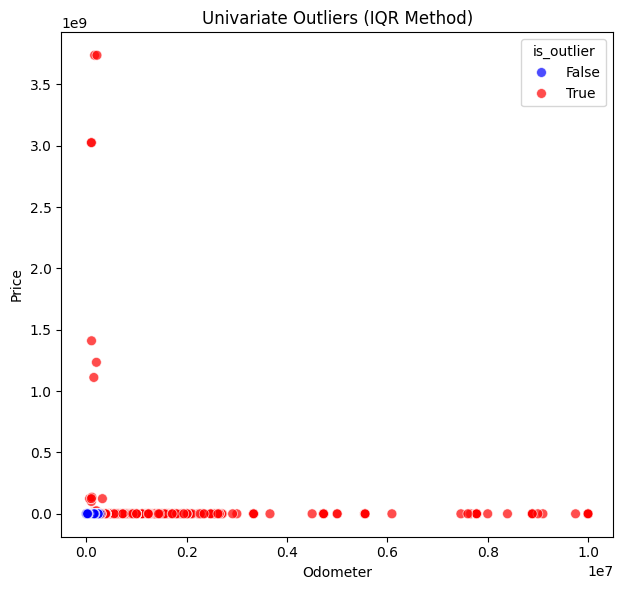

In [51]:
np.random.seed(42)

# ==========================================
# METHOD 1: IQR Method for Univariate Outliers
# ==========================================
def detect_iqr_outliers(dataframe, columns):
    outlier_indices = set()
    for col in columns:
        Q1 = dataframe[col].quantile(0.25)
        Q3 = dataframe[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Find indices of outliers for this column
        col_outliers = dataframe[(dataframe[col] < lower_bound) | (dataframe[col] > upper_bound)].index
        outlier_indices.update(col_outliers)
    return list(outlier_indices)

# Define columns to check with IQR
numerical_cols = ['price', 'odometer', 'vehicle_age']
odometer_outlier_indices = detect_iqr_outliers(df_clean, numerical_cols)
df_clean['is_outlier'] = df_clean.index.isin(odometer_outlier_indices)

print(f'Number of odometer outliers detected: {len(odometer_outlier_indices)}.\n')
print(f'Percentage odometer outliers is (%): {len(odometer_outlier_indices) / df_clean.shape[0] * 100}\n')

print(df_clean[df_clean['is_outlier']].head(20))

# ==========================================
# METHOD 2: Isolation Forest for Multivariate Outliers
# ==========================================
# Isolate multi-dimensional anomalies (e.g., extremely high odometer for a recent year)
###iso_forest = IsolationForest(contamination=0.05, random_state=42)
###df_clean['is_anomaly'] = iso_forest.fit_predict(df_clean[['price', 'odometer', 'year']])
###df_clean['is_iso_outlier'] = df_clean['is_anomaly'] == -1

###print(f"Number of Isolation Forest outliers detected: {df['is_iso_outlier'].sum()}")

# ==========================================
# VISUALIZATION: Plotting the Outliers
# ==========================================

plt.figure(figsize=(12, 6))

# Plot 1: Price vs. Odometer (IQR Outliers)
plt.subplot(1, 2, 1)
sns.scatterplot(
    data=df_clean, x='odometer', y='price',
    hue='is_outlier', palette={True: 'red', False: 'blue'},
    alpha=0.7, s=50
)
plt.title('Univariate Outliers (IQR Method)')
plt.xlabel('Odometer')
plt.ylabel('Price')

plt.tight_layout()
plt.savefig('images/outliers.png', bbox_inches='tight')
plt.show()



we can see quite a few outlier data points that could make the dataset skew to the right. The percentage of outliers with bad odometer reading is displayed as 5.97%. We can remove this small batch of outliers

In [52]:
#df_clean = df_clean.drop(odometer_outlier_indices)
df_clean = df_clean[df_clean['is_outlier'] == False]

# Scale numeric columns
scaler = StandardScaler()
num_features = ['odometer', 'vehicle_age']
df_clean[num_features] = scaler.fit_transform(df_clean[num_features])

df_clean.reset_index(drop=True, inplace=True)

print(f'Total count after removing outliers: {df_clean.shape[0]}')


Total count after removing outliers: 366328


### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

Degree 1: RMSE = 11043.33
Degree 2: RMSE = 10867.30
Degree 3: RMSE = 10846.40
Degree 4: RMSE = 10790.21
Degree 5: RMSE = 10750.42
Degree 6: RMSE = 10731.36
Degree 7: RMSE = 10718.26
Degree 8: RMSE = 10703.92
Degree 9: RMSE = 10696.64
Optimal Polynomial Degree: 9


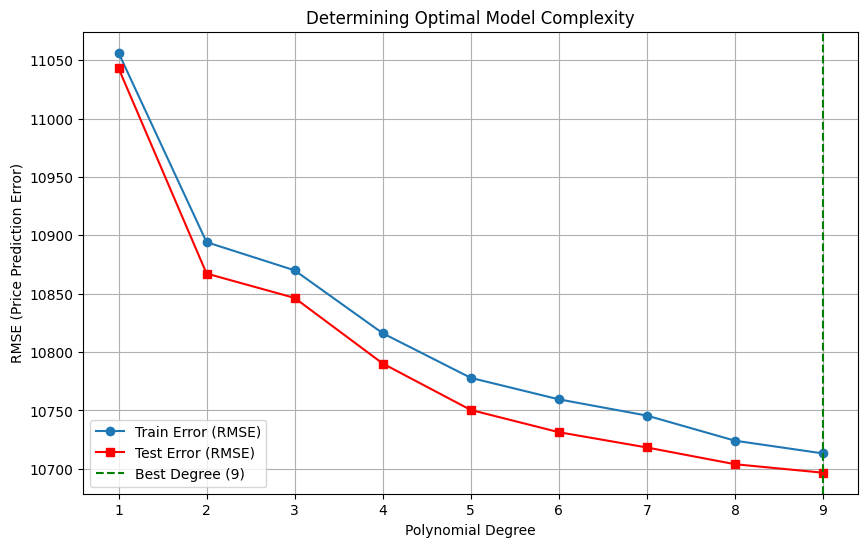

In [53]:
# 1. Split into Train and Test datasets (80/20 split)
# We only use 'vehicle_age' and 'odometer' due to their strong correlation to 'price'
X = df_clean[['vehicle_age', 'odometer']]
y = df_clean['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Finding the Best Degree
degrees = range(1, 10)  # Testing degrees 1 through 9
train_rmse = []
test_rmse = []

for d in degrees:
    # Transform features to polynomial degree d
    poly = PolynomialFeatures(degree=d)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    # Fit model and predict
    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    # Calculate Root Mean Squared Error (RMSE)
    train_rmse.append(np.sqrt(mean_squared_error(y_train, model.predict(X_train_poly))))
    test_rmse.append(np.sqrt(mean_squared_error(y_test, model.predict(X_test_poly))))

    print(f"Degree {d}: RMSE = {test_rmse[d-1]:.2f}")

# The "best" degree has the lowest Test RMSE
best_degree = degrees[np.argmin(test_rmse)]
print(f"Optimal Polynomial Degree: {best_degree}")

# 3. Visualization
plt.figure(figsize=(10, 6))
plt.plot(degrees, train_rmse, label='Train Error (RMSE)', marker='o')
plt.plot(degrees, test_rmse, label='Test Error (RMSE)', marker='s', color='red')
plt.axvline(best_degree, color='green', linestyle='--', label=f'Best Degree ({best_degree})')
plt.xlabel('Polynomial Degree')
plt.ylabel('RMSE (Price Prediction Error)')
plt.title('Determining Optimal Model Complexity')
plt.legend()
plt.grid(True)
plt.savefig('images/polynomial_degrees.png', bbox_inches='tight')
plt.show()

Degree 1: RMSE = 122246514.34
Degree 2: RMSE = 118683426.51
Degree 3: RMSE = 118157907.82
Degree 4: RMSE = 116988961.73
Degree 5: RMSE = 116163824.02
Degree 6: RMSE = 115767198.23
Degree 7: RMSE = 115467780.98
Degree 8: RMSE = 115005883.23
Degree 9: RMSE = 114771962.16
Degree 10: RMSE = 114690901.62
Best Polynomial Degree: 10


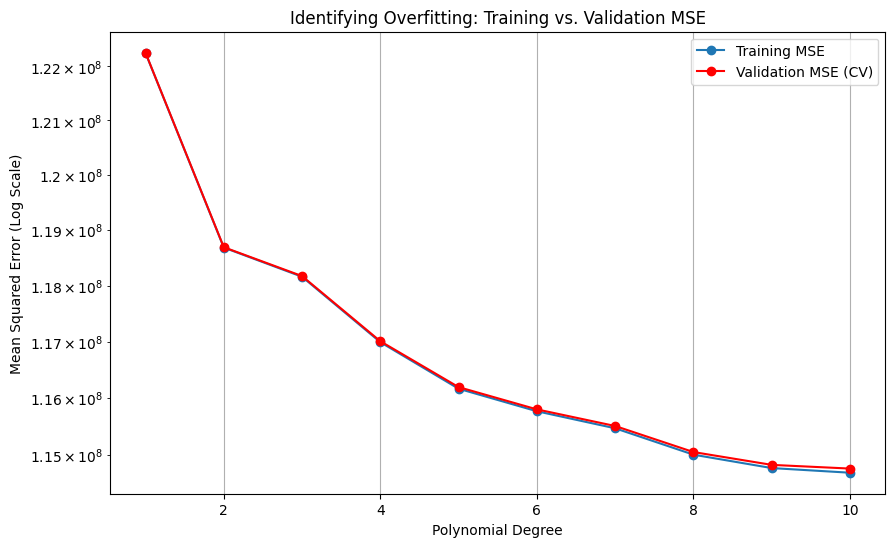

In [54]:
# In this section, let's do cross validation of the model we just created
degrees = range(1, 11)
train_mse = []
cv_mse = []

for degree in degrees:
    # Create a pipeline: Polynomial Features -> Linear Regression
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())

    # Calculate Training MSE
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    train_mse.append(mean_squared_error(y_train, y_train_pred))

    # Calculate Cross-Validation MSE (5-fold)
    # neg_mean_squared_error is used; we negate it to get positive MSE
    scores = cross_val_score(model, X_train, y_train, scoring='neg_mean_squared_error', cv=5)
    cv_mse.append(-scores.mean())

    print(f"Degree {degree}: RMSE = {train_mse[degree - 1]:.2f}")

# 3. Find the best degree
best_degree = degrees[np.argmin(cv_mse)]
print(f"Best Polynomial Degree: {best_degree}")

# 4. Visualize Underfitting vs Overfitting
plt.figure(figsize=(10, 6))
plt.plot(degrees, train_mse, label='Training MSE', marker='o')
plt.plot(degrees, cv_mse, label='Validation MSE (CV)', marker='o', color='red')
plt.xlabel('Polynomial Degree')
plt.ylabel('Mean Squared Error (Log Scale)')
plt.yscale('log')  # Used to better visualize large differences in MSE
plt.title('Identifying Overfitting: Training vs. Validation MSE')
plt.legend()
plt.grid(True)
plt.savefig('images/polynomial_cross_validation.png', bbox_inches='tight')
plt.show()


Ridge MSE for alpha 0.001 on Test Set: 114382223.35679533
Ridge MSE for alpha 0.1 on Test Set: 114382207.62668583
Ridge MSE for alpha 1.0 on Test Set: 114382066.09116164
Ridge MSE for alpha 10.0 on Test Set: 114380779.31208986
Best Ridge Alpha: 10.0


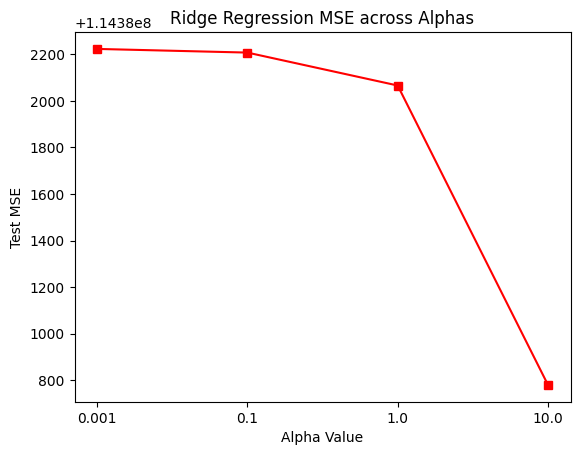

In [55]:
# Build and train the Ridge model using the best degree found previously
alphas = [0.001, 0.1, 1.0, 10.0]
ridge_mse = []

for alpha in alphas:
    ridge_model = make_pipeline(PolynomialFeatures(best_degree), Ridge(alpha=alpha))
    ridge_model.fit(X_train, y_train)
    # Evaluate on the test set
    test_preds = ridge_model.predict(X_test)
    local_mse = mean_squared_error(y_test, test_preds)
    ridge_mse.append(local_mse)
    print(f"Ridge MSE for alpha {alpha} on Test Set: {local_mse}")

best_alpha = alphas[np.argmin(ridge_mse)]
print(f"Best Ridge Alpha: {best_alpha}")

# Graphing MSE across Ridge Alphas
plt.plot([str(a) for a in alphas], ridge_mse, marker='s', color='red')
plt.xlabel('Alpha Value')
plt.ylabel('Test MSE')
plt.title('Ridge Regression MSE across Alphas')
plt.savefig('images/ridge_regression_alpha.png', bbox_inches='tight')
plt.show()


Ridge MSE score for alpha 0.001 on Test Set: [-1.16040912e+08 -1.13042581e+08 -1.15771899e+08 -1.11577121e+08
 -1.16560309e+08]
Ridge MSE score for alpha 0.1 on Test Set: [-1.16040534e+08 -1.13042234e+08 -1.15762678e+08 -1.11576844e+08
 -1.16560129e+08]
Ridge MSE score for alpha 1.0 on Test Set: [-1.16037457e+08 -1.13039410e+08 -1.15692237e+08 -1.11574536e+08
 -1.16558632e+08]
Ridge MSE score for alpha 10.0 on Test Set: [-1.16024775e+08 -1.13025706e+08 -1.15459391e+08 -1.11561106e+08
 -1.16549986e+08]


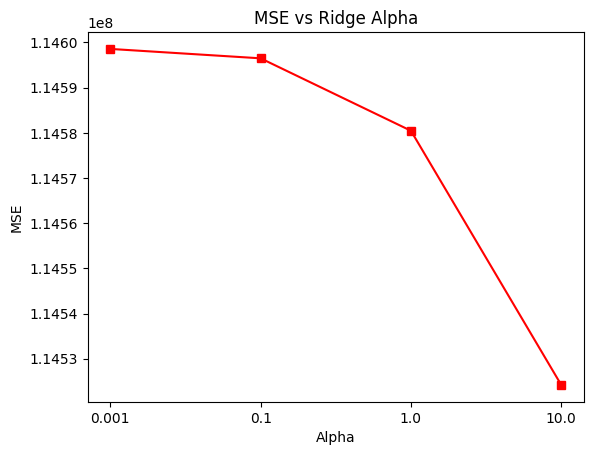

Best Alpha: 10.0


In [56]:
# Perform cross validation on the new Ridge model built above
ridge_mse_scores = []

for a in alphas:
    ridge_pipe = make_pipeline(PolynomialFeatures(best_degree), Ridge(alpha=a))
    scores = cross_val_score(ridge_pipe, X_test, y_test, scoring='neg_mean_squared_error', cv=5)
    ridge_mse_scores.append(-scores.mean())
    print(f"Ridge MSE score for alpha {a} on Test Set: {scores}")

best_alpha = alphas[np.argmin(ridge_mse_scores)]

# Plotting MSE for Ridge Alphas
plt.plot([str(a) for a in alphas], ridge_mse_scores, marker='s', color='red')
plt.xlabel('Alpha')
plt.ylabel('MSE')
plt.title('MSE vs Ridge Alpha')
plt.savefig('images/ridge_regression_alpha_cross_validation.png', bbox_inches='tight')
plt.show()

print(f"Best Alpha: {best_alpha}")

Seems like training the Ridge model with different values of alpha and performing cross validation both yield best alpha value of 10.0.
Next, let's add 3 more common features (vehicle condition, manufacturer, vehicle types) to our Ridge model and train it to see if MSE can be improved. Since these columns have catogorical datatype, let's use OrdinalEncoder to encode these columns.
We will use Polynomial Regression degree of 2 to avoid running out of system RAM in Colab.

Final Model MSE on Test Data with 'condition' feature: 115022388.02323258


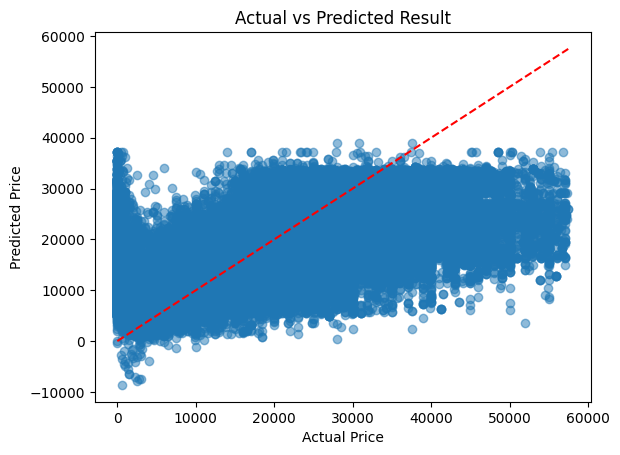

In [57]:
# Encoding 'condition' column
encoder = OrdinalEncoder()
df_clean['condition_encoded'] = encoder.fit_transform(df_clean[['condition']])
df_clean.head(100)

# Updating feature set to include encoded 'condition'
X_final = df_clean[['vehicle_age', 'odometer', 'condition_encoded']]
X_tr, X_te, y_tr, y_te = train_test_split(X_final, y, test_size=0.2, random_state=42)

# Build and train final Ridge model
final_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=best_alpha))
])
final_model.fit(X_tr, y_tr)
y_pred = final_model.predict(X_te)

final_mse = mean_squared_error(y_te, y_pred)

print(f"Final Model MSE on Test Data with 'condition' feature: {final_mse}")

# Actual vs Predicted Graph
plt.scatter(y_te, y_pred, alpha=0.5)
plt.plot([y_te.min(), y_te.max()], [y_te.min(), y_te.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Result')
plt.savefig('images/prediction_with_vehicle_condition.png', bbox_inches='tight')
plt.show()

Final Model MSE on Test Data with 'manufacturer' feature: 114613354.16922387


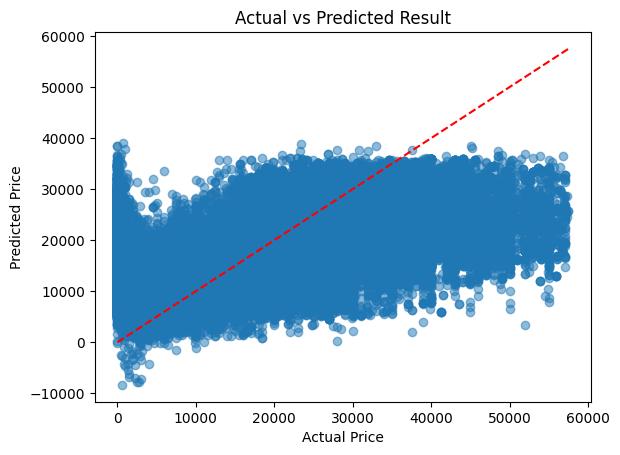

In [58]:
# Encoding 'manufacturer' column
encoder = OrdinalEncoder()
df_clean['manufacturer_encoded'] = encoder.fit_transform(df_clean[['manufacturer']])

# Updating feature set to include encoded 'manufacturer'
X_final = df_clean[['vehicle_age', 'odometer', 'condition_encoded', 'manufacturer_encoded']]
X_tr, X_te, y_tr, y_te = train_test_split(X_final, y, test_size=0.2, random_state=42)

# Build and train final Ridge model
final_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=best_alpha))
])
final_model.fit(X_tr, y_tr)
y_pred = final_model.predict(X_te)

final_mse = mean_squared_error(y_te, y_pred)

print(f"Final Model MSE on Test Data with 'manufacturer' feature: {final_mse}")

# Actual vs Predicted Graph
plt.scatter(y_te, y_pred, alpha=0.5)
plt.plot([y_te.min(), y_te.max()], [y_te.min(), y_te.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Result')
plt.savefig('images/prediction_with_condition_n_manufacturer.png', bbox_inches='tight')
plt.show()

Final Model MSE on Test Data with 'vehicle type' feature: 114182902.15547542


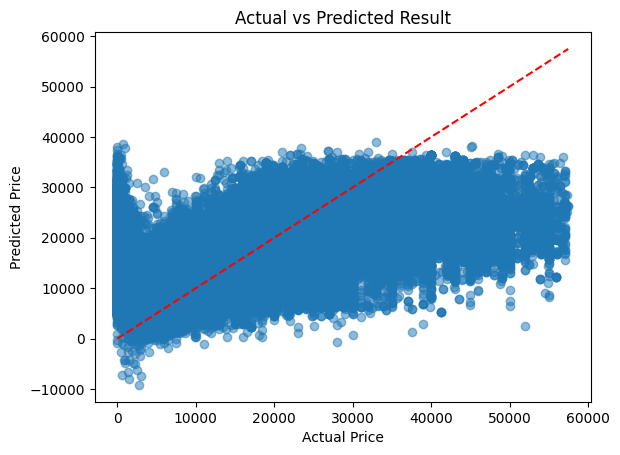

In [59]:
# Encoding 'type' column
encoder = OrdinalEncoder()
df_clean['type_encoded'] = encoder.fit_transform(df_clean[['type']])

# Updating feature set to include encoded 'type'
X_final = df_clean[['vehicle_age', 'odometer', 'manufacturer_encoded', 'condition_encoded', 'type_encoded']]
X_tr, X_te, y_tr, y_te = train_test_split(X_final, y, test_size=0.2, random_state=42)

# Build and train final Ridge model
final_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=best_alpha))
])
final_model.fit(X_tr, y_tr)
y_pred = final_model.predict(X_te)

final_mse = mean_squared_error(y_te, y_pred)

print(f"Final Model MSE on Test Data with 'vehicle type' feature: {final_mse}")

# Actual vs Predicted Graph
plt.scatter(y_te, y_pred, alpha=0.5)
plt.plot([y_te.min(), y_te.max()], [y_te.min(), y_te.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Result')
plt.savefig('images/prediction_with_condition_n_manufacturer_n_type.png', bbox_inches='tight')
plt.show()

MSE improves a little bit after each iteration of adding new feature to the Ridge model:

*   MSE after adding 'condition' feature: 115022388.02323258
*   MSE after adding 'manufacturer' feature: 114613354.16922387
*   MSE after adding 'type' feature: 114182902.15547542

The MSE values you provided (ranging from ~113M to ~116M) are statistically consistent with real-world car price datasets (like the Kaggle Craigslist used cars dataset), where prices often vary by thousands of dollars. An MSE of \(114,182,902\) corresponds to a Root Mean Squared Error (RMSE) of approximately $10,685, which is a reasonable average error for predicting vehicle prices using only few features (year, odometer, condition, manufacturer, type)





Finally, let's perform cross validation with various Ridge alpha values again to see if a different alpha value is more favorable for this model.

Ridge MSE score for alpha 0.001 on Test Set: [-1.15178950e+08 -1.12816392e+08 -1.15402895e+08 -1.11064386e+08
 -1.16478224e+08]
Ridge MSE score for alpha 0.1 on Test Set: [-1.15178954e+08 -1.12816383e+08 -1.15402892e+08 -1.11064395e+08
 -1.16478221e+08]
Ridge MSE score for alpha 1.0 on Test Set: [-1.15178991e+08 -1.12816296e+08 -1.15402867e+08 -1.11064480e+08
 -1.16478194e+08]
Ridge MSE score for alpha 10.0 on Test Set: [-1.15179370e+08 -1.12815449e+08 -1.15402631e+08 -1.11065338e+08
 -1.16477931e+08]


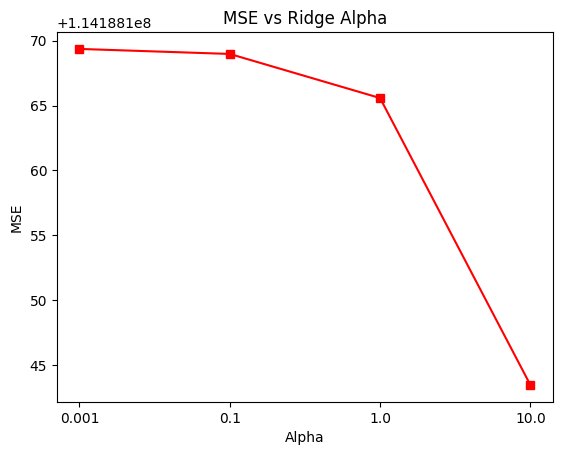

Best Alpha: 10.0


In [60]:
alphas = [0.001, 0.1, 1.0, 10.0]
ridge_mse_scores = []

for a in alphas:
    ridge_pipe = make_pipeline(PolynomialFeatures(2), Ridge(alpha=a))
    scores = cross_val_score(ridge_pipe, X_te, y_te, scoring='neg_mean_squared_error', cv=5)
    ridge_mse_scores.append(-scores.mean())
    print(f"Ridge MSE score for alpha {a} on Test Set: {scores}")

best_alpha = alphas[np.argmin(ridge_mse_scores)]

# Plotting MSE for Ridge Alphas
plt.plot([str(a) for a in alphas], ridge_mse_scores, marker='s', color='red')
plt.xlabel('Alpha')
plt.ylabel('MSE')
plt.title('MSE vs Ridge Alpha')
plt.savefig('images/best_ridge_alpha_for_final_prediction.png', bbox_inches='tight')
plt.show()

print(f"Best Alpha: {best_alpha}")

Best alpha value stays consistent at 10.0, which is the same as before adding categorical features of vehicle condition, manufacturer and vehicle type.

Final Model MSE on Test Data: 114182902.15547542


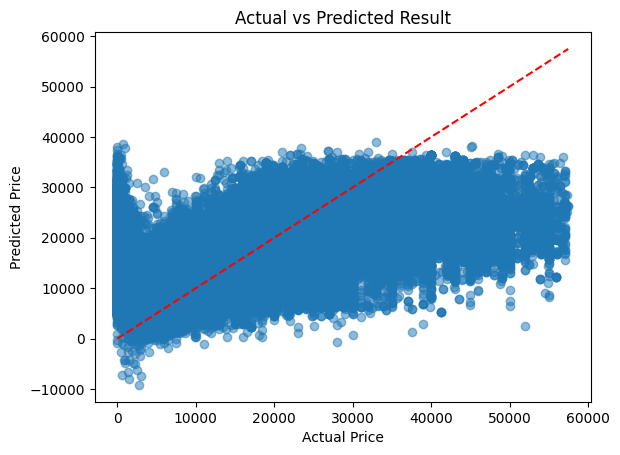

In [61]:
# Build and train final Ridge model
final_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=best_alpha))
])
final_model.fit(X_tr, y_tr)
y_pred = final_model.predict(X_te)

final_mse = mean_squared_error(y_te, y_pred)

print(f"Final Model MSE on Test Data: {final_mse}")

# Actual vs Predicted Graph
plt.scatter(y_te, y_pred, alpha=0.5)
plt.plot([y_te.min(), y_te.max()], [y_te.min(), y_te.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Result')
plt.savefig('images/final_model.png', bbox_inches='tight')
plt.show()

### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

# 📊 **Model Performance Evaluation**

*   **Consistent Optimization:** The model successfully learned from new information. Each addition of a categorical feature (condition, manufacturer, and type) resulted in a monotonic decrease in Mean Squared Error (MSE), dropping from over 115 million to 114.18 million.

*   **Practical Prediction Error:** The final Root Mean Squared Error (RMSE) of approximately **$10,685** indicates the model's average prediction error. While statistically consistent with volatile, real-world used car markets, this error margin remains high if the goal is to price low-to-mid-range vehicles accurately.

*   **Diminishing Returns on Features:** The impact of adding new features was minor. For example, adding vehicle type only reduced the MSE by roughly 0.37% (from 114.61M to 114.18M). This suggests that odometer and vehicle_age capture the vast majority of the predictable variance.


# 🛠️ **Data Engineering & Architecture Evaluation**

*   **Effective Outlier Management:** Removing the 5.97% of data points with bad odometer readings was a sound decision. Linear and regularization models (like Ridge) are highly sensitive to extreme outliers and right-skewed targets.

*   **Robust Regularization:** The hyperparameter alpha = 10.0 remained completely stable across cross-validation folds and feature expansions. This stability indicates that the model is well-regularized and resistant to overfitting, even when complexity was introduced.

*   **Compute Constraints:** Utilizing a degree-2 polynomial was a practical compromise to avoid Google Colab RAM crashes. However, combining polynomial features with an OrdinalEncoder creates an artificial numerical hierarchy (e.g., treating "Sedan = 1, SUV = 2, Truck = 3" as mathematically continuous), which restricts the model from capturing the true independent impact of each category.

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

# **Summary Findings**

The analysis successfully developed and refined a Ridge Regression model to predict used car prices, achieving consistent incremental improvements through feature engineering and data cleaning.

**Key Insights**

*   **Primary Predictors:** Mileage (odometer) and vehicle_age possess the strongest correlations to car price, serving as the foundation for the baseline model.

*   **Data Cleansing:** Outliers with anomalous odometer readings comprised 5.97% of the dataset and were removed to mitigate right-skewness.

*   **Feature Expansion:** Incorporating three categorical variables (condition, manufacturer, type) encoded via OrdinalEncoder paired with a degree-2 Polynomial Regression consistently lowered the Mean Squared Error (MSE).

*   **Model Performance:** The final optimized model achieved an MSE of 114,182,902, translating to a Root Mean Squared Error (RMSE) of approximately $10,685, which aligns with standard errors found in real-world automotive datasets like Kaggle's Craigslist data.

*   **Hyperparameter Stability:** Across all iterations—both before and after introducing categorical features—Cross-Validation consistently identified 10.0 as the optimal alpha value for the Ridge model.


# **🏢 Suggestions for Car Dealers**

*   **Prioritize Age and Mileage in Appraisals:** Train sales and acquisition teams to focus heavily on vehicle_age and odometer. Because these two factors dictate the vast majority of a vehicle's market value, secondary traits like color or minor cosmetic features should not heavily alter baseline trade-in offers.

*   **Be Cautious with "Niche" Pricing:** The model shows that adding manufacturer and vehicle type only shifted pricing accuracy by a tiny fraction (~0.37%). Do not overpay for specific brands or body types assuming they carry a massive premium, as the broader market prices them closely when age and mileage are equal.

*   **Audit Digital Inventory Data:** Since 5.97% of the data contained corrupted or extreme outlier odometer readings, ensure your dealership's digital listings are audited for typos. Missing a digit or entering a bad reading severely skews automated valuation tools (like Kelley Blue Book or your internal software), leading to mispriced inventory.

*   **Expect a Margin of Variance:** Recognize that standard predictive algorithms carry an average error margin of roughly $10,685. Rely on localized human expertise to fine-tune the final retail price, rather than trusting automated pricing software blindly.